# 03 — Evaluation Dashboard
Run all metrics and display a comprehensive evaluation of generated question sets.

In [ ]:
import json, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Use absolute path relative to this notebook file
NOTEBOOK_DIR = Path(__file__).parent if "__file__" in dir() else Path.cwd()
AI_DIR   = NOTEBOOK_DIR.parent        # ai/
DATASET  = AI_DIR / "dataset"
RATED    = DATASET / "rated"
GENERATED = DATASET / "generated"
RESULTS  = AI_DIR / "eval" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(AI_DIR))
from eval.metrics import evaluate

DATA_DIRS = [d for d in [GENERATED, RATED] if d.exists() and any(d.glob("*.json"))]

print(f"AI_DIR   : {AI_DIR}")
print(f"RATED    : {RATED}  → exists={RATED.exists()}, files={len(list(RATED.glob('*.json')))}")
print(f"GENERATED: {GENERATED}  → exists={GENERATED.exists()}, files={len(list(GENERATED.glob('*.json')))}")
print(f"DATA_DIRS: {[str(d) for d in DATA_DIRS]}")

## Run evaluation on all files

In [ ]:
reports = []
seen = set()  # deduplicate by filename stem
for data_dir in DATA_DIRS:
    for f in sorted(data_dir.glob("*.json")):
        if f.name in seen:
            continue
        seen.add(f.name)
        try:
            questions = json.loads(f.read_text(encoding="utf-8"))
        except Exception as e:
            print(f"  ⚠ skip {f.name}: {e}")
            continue
        if not questions:
            continue
        report = evaluate(questions)
        report["file"]      = f.name
        report["game_type"] = questions[0].get("game_type", "?")
        report["source"]    = questions[0].get("source_doc", f.stem)
        report["folder"]    = data_dir.name
        reports.append(report)
        status = "✓ PASS" if report["pass"] else "✗ FAIL"
        print(f"{status}  [{data_dir.name}]  {f.name:<50}  diversity={report['diversity_score']:.3f}  balance={report['balance_score']:.2f}")

print(f"\nTotal: {sum(r['pass'] for r in reports)}/{len(reports)} passed")

## Metrics overview table

In [ ]:
if not reports:
    print("⚠ No reports — check output of the first cell to see if DATA_DIRS found any files")
else:
    rows = []
    for r in reports:
        rows.append({
            "File":       r["file"],
            "Game":       r["game_type"],
            "N":          r["n_questions"],
            "Balance":    r["balance_score"],
            "Diversity":  r["diversity_score"],
            "Relevance":  r.get("relevance_score", "-"),
            "Fmt OK":     r["format_validity"]["pass_rate"],
            "Pass":       "✓" if r["pass"] else "✗",
        })
    pd.DataFrame(rows).set_index("File")

## Radar chart — metric comparison per game type

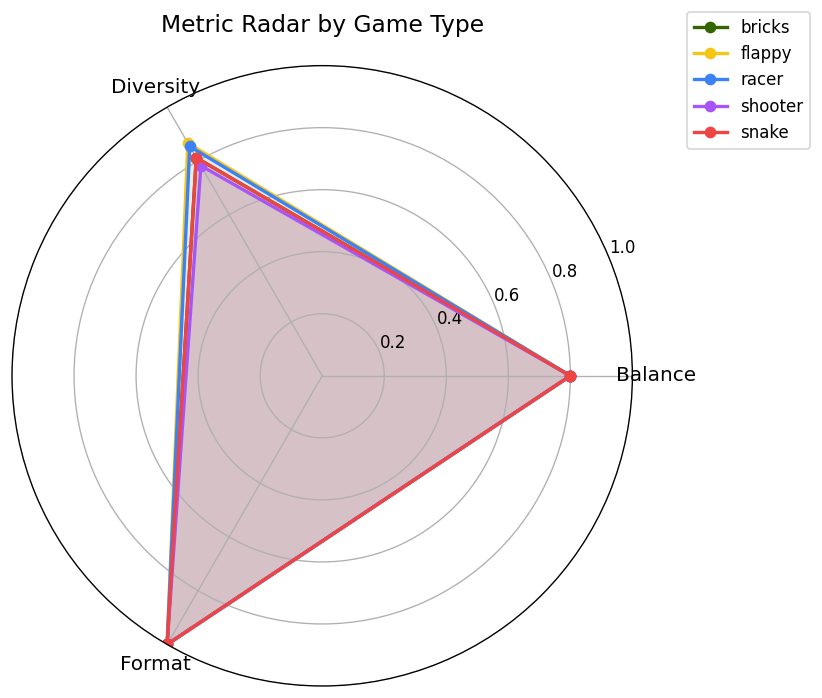

Saved: eval/results/radar_chart.png


In [14]:
import numpy as np

game_reports = {}
for r in reports:
    g = r["game_type"]
    if g not in game_reports:
        game_reports[g] = {"balance": [], "diversity": [], "fmt": []}
    game_reports[g]["balance"].append(r["balance_score"])
    game_reports[g]["diversity"].append(r["diversity_score"])
    game_reports[g]["fmt"].append(r["format_validity"]["pass_rate"])

games = list(game_reports.keys())
categories = ["Balance", "Diversity", "Format"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = ["#336600", "#f5c518", "#3b82f6", "#a855f7", "#ef4444"]

for idx, (game, color) in enumerate(zip(games, colors)):
    vals = [
        np.mean(game_reports[game]["balance"]),
        np.mean(game_reports[game]["diversity"]),
        np.mean(game_reports[game]["fmt"]),
    ]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=game, color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_title("Metric Radar by Game Type", size=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(RESULTS / "radar_chart.png", bbox_inches="tight")
plt.show()
print("Saved: eval/results/radar_chart.png")

## Save full report

In [15]:
from datetime import datetime

out = RESULTS / f"eval_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
out.write_text(json.dumps({"timestamp": datetime.now().isoformat(), "reports": reports},
                            ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Full report saved → {out}")

Full report saved → ../eval/results/eval_20260226_190014.json


---
## Fine-tuned model evaluation
Compare base Qwen2.5-7B vs fine-tuned LoRA adapter output quality.
Requires vLLM running at `AI_BASE_URL` (default `http://localhost:8000/v1`).

In [ ]:
import os, re, requests, time

AI_BASE_URL = os.getenv("AI_BASE_URL", "http://localhost:8000/v1")
AI_MODEL    = os.getenv("AI_MODEL",    "Qwen/Qwen2.5-7B-Instruct-AWQ")

# Check if vLLM is reachable
try:
    r = requests.get(f"{AI_BASE_URL}/models", timeout=5)
    models = [m["id"] for m in r.json().get("data", [])]
    print(f"✅ vLLM online — models: {models}")
except Exception as e:
    print(f"❌ vLLM not reachable at {AI_BASE_URL}: {e}")
    print("   Start vLLM with:  sbatch ~/ku_prep_arena/ai/scripts/slurm_vllm.sh")
    print("   Then tunnel:      ssh -N -L 8000:dgx-XX:8000 aip04@br1.paas.ku.ac.th")

In [ ]:
GAME_PROMPTS = {
    "flappy":  ("short ≤12 words true/false", 2),
    "racer":   ("≤12 word answer options",    4),
    "shooter": ("'Which term describes...'",  4),
    "snake":   ("sequential/process",         4),
    "bricks":  ("definition",                 4),
}

SYSTEM_PROMPT = (
    "You are KU Quiz Generator. Output ONLY a valid JSON array of question objects. "
    "Each object: {\"id\":int,\"question\":str,\"choices\":[str,...],\"correct\":int(0-indexed),"
    "\"explanation\":str,\"difficulty\":int(1-3),\"game_type\":str}"
)

TEST_CONTEXT = (
    "Context: In Python, a list is a mutable, ordered collection. "
    "A tuple is immutable. A dictionary stores key-value pairs. "
    "Sets contain unique elements. Functions are defined with 'def'. "
    "Classes use 'class'. Loops: for/while. Conditionals: if/elif/else."
)

def generate_questions(game_type: str, n: int = 5, model: str = AI_MODEL) -> list:
    hint, n_choices = GAME_PROMPTS[game_type]
    user_msg = (
        f"{TEST_CONTEXT}\n\n"
        f"Generate {n} {game_type} questions. Style: {hint}. "
        f"Each question must have exactly {n_choices} choices. "
        f"game_type field = \"{game_type}\". Vary difficulty 1/2/3."
    )
    resp = requests.post(
        f"{AI_BASE_URL}/chat/completions",
        json={"model": model, "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_msg},
        ], "temperature": 0.7, "max_tokens": 2048},
        timeout=60,
    )
    resp.raise_for_status()
    raw = resp.json()["choices"][0]["message"]["content"].strip()
    # strip markdown fences
    raw = re.sub(r"^```(?:json)?\s*", "", raw)
    raw = re.sub(r"\s*```$", "", raw)
    return json.loads(raw)

print("generate_questions() helper ready")

In [ ]:
# ── Run inference on all 5 game types and collect metrics ──
ft_reports = []
for game_type in ["flappy", "racer", "shooter", "snake", "bricks"]:
    print(f"  generating {game_type}...", end=" ", flush=True)
    t0 = time.time()
    try:
        qs = generate_questions(game_type, n=10)
        # patch game_type if model forgot
        for q in qs:
            q.setdefault("game_type", game_type)
        report = evaluate(qs)
        report["game_type"] = game_type
        report["n_qs"]      = len(qs)
        report["latency_s"] = round(time.time() - t0, 1)
        ft_reports.append(report)
        mark = "✓" if report["pass"] else "✗"
        print(f"{mark}  {len(qs)} qs  balance={report['balance_score']:.2f}  "
              f"diversity={report['diversity_score']:.3f}  fmt={report['format_validity']['pass_rate']:.2f}  "
              f"[{report['latency_s']}s]")
        # choice-count check for flappy
        if game_type == "flappy":
            wrong = [q for q in qs if len(q.get("choices", [])) != 2]
            if wrong:
                print(f"    ⚠ {len(wrong)} flappy questions have wrong choice count!")
    except Exception as e:
        print(f"ERROR: {e}")

print(f"\nFine-tuned pass rate: {sum(r['pass'] for r in ft_reports)}/{len(ft_reports)}")

In [ ]:
import numpy as np

if not ft_reports:
    print("No fine-tuned results — run inference cell above first")
else:
    # ── Compare base data vs fine-tuned output ──
    base_by_game = {}
    for r in reports:
        g = r["game_type"]
        base_by_game.setdefault(g, {"balance":[], "diversity":[], "fmt":[]})
        base_by_game[g]["balance"].append(r["balance_score"])
        base_by_game[g]["diversity"].append(r["diversity_score"])
        base_by_game[g]["fmt"].append(r["format_validity"]["pass_rate"])

    ft_by_game = {r["game_type"]: r for r in ft_reports}

    rows = []
    for g in ["flappy", "racer", "shooter", "snake", "bricks"]:
        base = base_by_game.get(g, {})
        ft   = ft_by_game.get(g)
        rows.append({
            "Game":           g,
            "Base Balance":   f"{np.mean(base.get('balance', [0])):.2f}" if base else "-",
            "FT Balance":     f"{ft['balance_score']:.2f}" if ft else "-",
            "Base Diversity": f"{np.mean(base.get('diversity', [0])):.3f}" if base else "-",
            "FT Diversity":   f"{ft['diversity_score']:.3f}" if ft else "-",
            "Base Fmt":       f"{np.mean(base.get('fmt', [0])):.2f}" if base else "-",
            "FT Fmt":         f"{ft['format_validity']['pass_rate']:.2f}" if ft else "-",
            "FT Pass":        "✓" if (ft and ft["pass"]) else "✗",
        })

    df = pd.DataFrame(rows).set_index("Game")
    print(df.to_string())

    # ── Bar chart ──
    games = [r["game"] for r in rows if ft_by_game.get(r["game"] if "game" in r else r.get("Game",""))]
    # Rebuild cleanly
    game_labels = [r["Game"] for r in rows]
    base_div    = [float(r["Base Diversity"]) if r["Base Diversity"] != "-" else 0 for r in rows]
    ft_div      = [float(r["FT Diversity"])   if r["FT Diversity"]   != "-" else 0 for r in rows]
    base_bal    = [float(r["Base Balance"])    if r["Base Balance"]   != "-" else 0 for r in rows]
    ft_bal      = [float(r["FT Balance"])      if r["FT Balance"]     != "-" else 0 for r in rows]

    x = np.arange(len(game_labels))
    w = 0.2
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, bvals, fvals, title in [
        (axes[0], "Diversity", base_div, ft_div,  "Diversity Score: Base vs Fine-tuned"),
        (axes[1], "Balance",   base_bal, ft_bal,  "Balance Score:   Base vs Fine-tuned"),
    ]:
        ax.bar(x - w/2, bvals, w, label="Base data", color="#336600", alpha=0.75)
        ax.bar(x + w/2, fvals, w, label="Fine-tuned",color="#C9A227", alpha=0.85)
        ax.set_xticks(x); ax.set_xticklabels(game_labels, rotation=20)
        ax.set_ylim(0, 1.05); ax.set_title(title, fontsize=12)
        ax.legend(); ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS / "agent_comparison.png", bbox_inches="tight")
    plt.show()
    print("Saved: eval/results/agent_comparison.png")